# Assignment 5 — Part 1: Transfer Learning for Image Classification (Chicken vs Duck)

## 1. Install dependencies

In [1]:
!pip -q install icrawler scikit-learn torch torchvision

## 2. Download images

In [2]:
import os, shutil
from icrawler.builtin import BingImageCrawler

ROOT = 'images'
if os.path.exists(ROOT):
    shutil.rmtree(ROOT)

QUERIES = {'chicken': 'chicken', 'duck': 'duck animal'}

for cls, query in QUERIES.items():
    out = os.path.join(ROOT, cls)
    crawler = BingImageCrawler(storage={'root_dir': out}, downloader_threads=4)
    crawler.crawl(keyword=query, max_num=120, min_size=(150, 150))

for cls in os.listdir(ROOT):
    print(cls, len(os.listdir(os.path.join(ROOT, cls))))

ERROR:downloader:Response status code 403, file https://lafeber.com/wp-content/uploads/2024/03/backyard-chicken-behavior.jpg
ERROR:downloader:Response status code 403, file https://run-chicken.com/wp-content/uploads/2024/09/0B1A6277-1024x683.jpg
ERROR:downloader:Response status code 403, file https://run-chicken.com/wp-content/uploads/2024/09/AlpakaRanc_2-2048x1366.jpg
ERROR:downloader:Response status code 403, file https://run-chicken.com/wp-content/uploads/2025/06/Izdelek-brez-naslova-57.jpg
ERROR:downloader:Exception caught when downloading file https://ogden_images.s3.amazonaws.com/www.iamcountryside.com/images/sites/3/2019/03/13132524/Origins1-1-1536x1167.jpg, error: HTTPSConnectionPool(host='ogden_images.s3.amazonaws.com', port=443): Max retries exceeded with url: /www.iamcountryside.com/images/sites/3/2019/03/13132524/Origins1-1-1536x1167.jpg (Caused by SSLError(SSLCertVerificationError(1, "[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: Hostname mismatch, certificat

chicken 40
duck 79


In [5]:
!pip -q install ddgs pillow requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 79.0 MB/s eta 0:00:00


In [6]:
import os, requests
from ddgs import DDGS
from PIL import Image
from io import BytesIO

out = 'images/chicken'
os.makedirs(out, exist_ok=True)
headers = {'User-Agent': 'Mozilla/5.0'}
existing = len(os.listdir(out))
target = 110

saved = 0
queries = ['chicken hen', 'rooster chicken', 'backyard chicken bird', 'chicken farm animal']
with DDGS() as ddg:
    for q in queries:
        if existing + saved >= target:
            break
        for r in ddg.images(q, max_results=80):
            if existing + saved >= target:
                break
            try:
                resp = requests.get(r['image'], headers=headers, timeout=8)
                img = Image.open(BytesIO(resp.content)).convert('RGB')
                if min(img.size) < 150:
                    continue
                img.save(f'{out}/ddg_{saved:03d}.jpg', 'JPEG')
                saved += 1
            except Exception:
                continue

print('added', saved, 'new chicken images')
for cls in os.listdir('images'):
    print(cls, len(os.listdir(f'images/{cls}')))

added 70 new chicken images
chicken 110
duck 79


### Filter out unreadable / non-image files

In [7]:
from PIL import Image

removed = 0
for cls in os.listdir(ROOT):
    cls_dir = os.path.join(ROOT, cls)
    for fname in os.listdir(cls_dir):
        fpath = os.path.join(cls_dir, fname)
        try:
            with Image.open(fpath) as im:
                im.convert('RGB')
        except Exception:
            os.remove(fpath)
            removed += 1
print(f'removed {removed} unreadable files')
for cls in os.listdir(ROOT):
    print(cls, len(os.listdir(os.path.join(ROOT, cls))))

removed 0 unreadable files
chicken 110
duck 79


## 3. Train / val / test split

In [8]:
import random
random.seed(42)

SPLIT_ROOT = 'data'
if os.path.exists(SPLIT_ROOT):
    shutil.rmtree(SPLIT_ROOT)

RATIOS = {'train': 0.7, 'val': 0.15, 'test': 0.15}

for cls in os.listdir(ROOT):
    files = os.listdir(os.path.join(ROOT, cls))
    random.shuffle(files)
    n = len(files)
    n_train = int(n * RATIOS['train'])
    n_val = int(n * RATIOS['val'])
    splits = {
        'train': files[:n_train],
        'val':   files[n_train:n_train + n_val],
        'test':  files[n_train + n_val:],
    }
    for split, flist in splits.items():
        dst = os.path.join(SPLIT_ROOT, split, cls)
        os.makedirs(dst, exist_ok=True)
        for f in flist:
            shutil.copy(os.path.join(ROOT, cls, f), os.path.join(dst, f))

for split in ['train', 'val', 'test']:
    for cls in os.listdir(os.path.join(SPLIT_ROOT, split)):
        n = len(os.listdir(os.path.join(SPLIT_ROOT, split, cls)))
        print(f'{split}/{cls}: {n}')

train/chicken: 77
train/duck: 55
val/chicken: 16
val/duck: 11
test/chicken: 17
test/duck: 13


## 4. DataLoaders with ImageNet-style transforms

ResNet18 expects 224x224 RGB inputs normalized with ImageNet means/stds. We add flips + crops for the training set as light augmentation.

In [9]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = datasets.ImageFolder('data/train', transform=train_tf)
val_ds   = datasets.ImageFolder('data/val',   transform=eval_tf)
test_ds  = datasets.ImageFolder('data/test',  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False, num_workers=2)

print('classes:', train_ds.classes)

classes: ['chicken', 'duck']


## 5. Load pre-trained ResNet18 and replace the final layer

We freeze all backbone weights and train only a new 2-unit FC head, then optionally unfreeze later layers for a short fine-tuning pass.

In [10]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for p in model.parameters():
    p.requires_grad = False

num_feats = model.fc.in_features
model.fc = nn.Linear(num_feats, len(train_ds.classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 224MB/s]


## 6. Train + validate

In [11]:
def run_epoch(loader, train):
    model.train(train)
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        with torch.set_grad_enabled(train):
            logits = model(x)
            loss = criterion(logits, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        n += x.size(0)
    return total_loss / n, correct / n

EPOCHS = 8
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)
    print(f'epoch {epoch:2d}  train loss {tr_loss:.4f} acc {tr_acc:.3f}  |  val loss {va_loss:.4f} acc {va_acc:.3f}')

epoch  1  train loss 0.6642 acc 0.621  |  val loss 0.5795 acc 0.704
epoch  2  train loss 0.5566 acc 0.735  |  val loss 0.3950 acc 0.852
epoch  3  train loss 0.4694 acc 0.773  |  val loss 0.3369 acc 0.889
epoch  4  train loss 0.3454 acc 0.902  |  val loss 0.2804 acc 0.926
epoch  5  train loss 0.3628 acc 0.818  |  val loss 0.2465 acc 0.926
epoch  6  train loss 0.3539 acc 0.871  |  val loss 0.3045 acc 0.852
epoch  7  train loss 0.2818 acc 0.902  |  val loss 0.1962 acc 0.963
epoch  8  train loss 0.2553 acc 0.902  |  val loss 0.2103 acc 0.926


In [12]:
for name, p in model.named_parameters():
    if name.startswith('layer4') or name.startswith('fc'):
        p.requires_grad = True

optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=1e-4)

for epoch in range(1, 4):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)
    print(f'ft epoch {epoch}  train loss {tr_loss:.4f} acc {tr_acc:.3f}  |  val loss {va_loss:.4f} acc {va_acc:.3f}')

ft epoch 1  train loss 0.1955 acc 0.970  |  val loss 0.1068 acc 0.963
ft epoch 2  train loss 0.1369 acc 0.962  |  val loss 0.0877 acc 0.963
ft epoch 3  train loss 0.0758 acc 0.977  |  val loss 0.0833 acc 0.963


## 7. Evaluate on the test set — classification report

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        preds = model(x).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y.numpy())

print('Classes:', train_ds.classes)
print('\nConfusion matrix:')
print(confusion_matrix(all_true, all_preds))
print('\nClassification report:')
print(classification_report(all_true, all_preds, target_names=train_ds.classes, digits=4))

Classes: ['chicken', 'duck']

Confusion matrix:
[[17  0]
 [ 2 11]]

Classification report:
              precision    recall  f1-score   support

     chicken     0.8947    1.0000    0.9444        17
        duck     1.0000    0.8462    0.9167        13

    accuracy                         0.9333        30
   macro avg     0.9474    0.9231    0.9306        30
weighted avg     0.9404    0.9333    0.9324        30



## 8. Save the fine-tuned model

In [14]:
torch.save(model.state_dict(), 'resnet18_chicken_duck.pt')
print('saved resnet18_chicken_duck.pt')

saved resnet18_chicken_duck.pt


### Sample Training Images

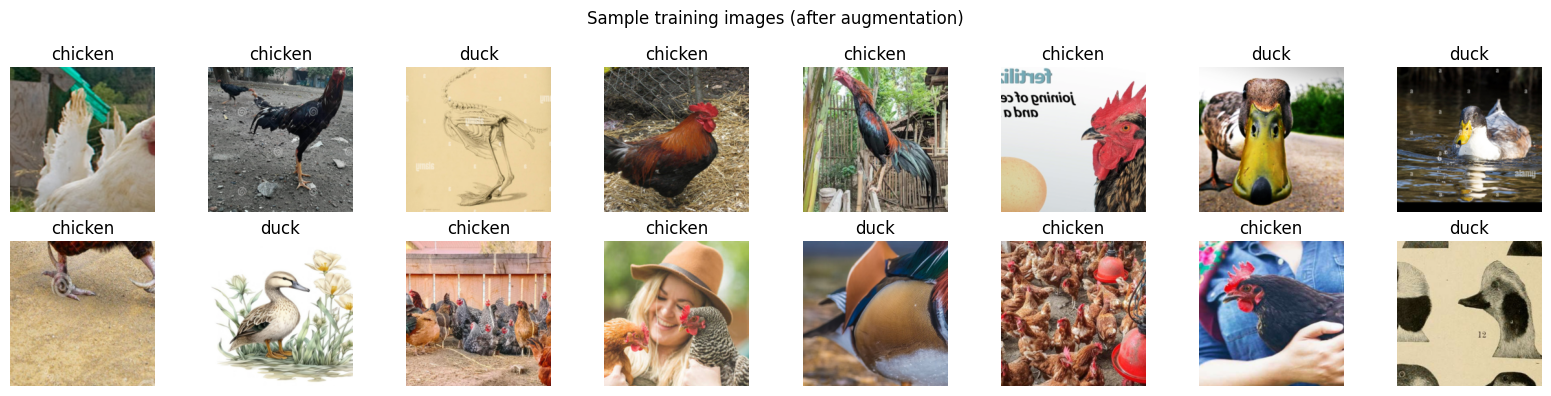

In [15]:
import matplotlib.pyplot as plt

def denorm(t):
    m = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    s = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t * s + m).clamp(0, 1)

xb, yb = next(iter(train_loader))
n = min(16, len(xb))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    if i >= n:
        ax.axis('off'); continue
    ax.imshow(denorm(xb[i]).permute(1, 2, 0))
    ax.set_title(train_ds.classes[yb[i]])
    ax.axis('off')
plt.suptitle('Sample training images (after augmentation)')
plt.tight_layout()
plt.show()

### Confusion matrix heatmap

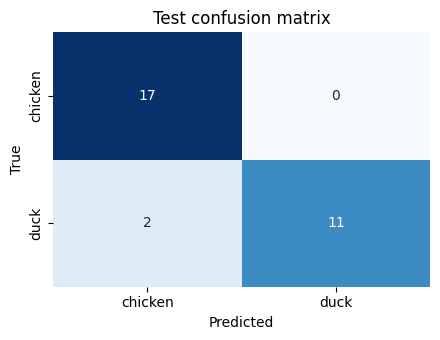

In [16]:
import seaborn as sns

cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(4.5, 3.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_ds.classes, yticklabels=train_ds.classes, cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Test confusion matrix')
plt.tight_layout()
plt.show()

## Cell 3 — Correctly classified vs misclassified test images

Green titles = correct, red titles = wrong.

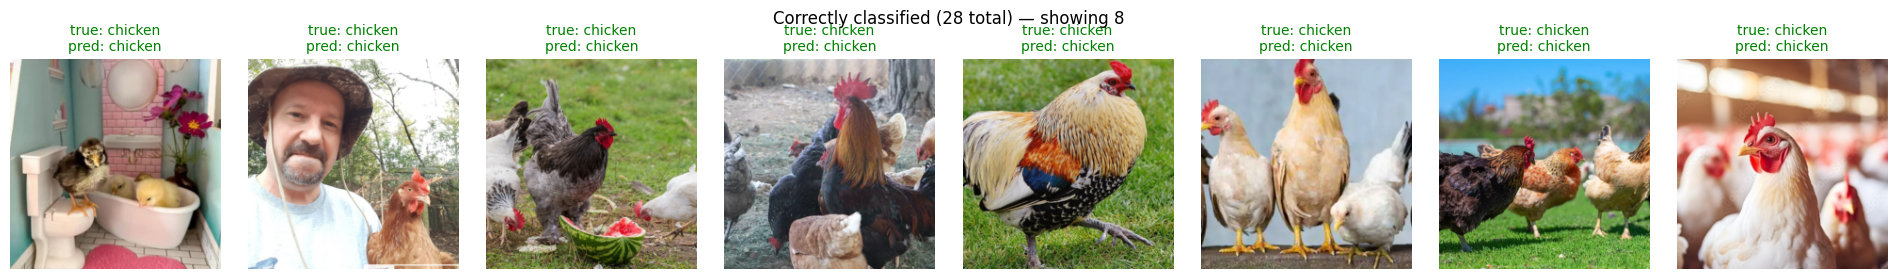

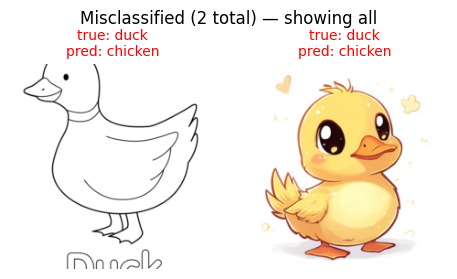

In [17]:
model.eval()
correct_imgs, wrong_imgs = [], []
with torch.no_grad():
    for x, y in test_loader:
        preds = model(x.to(device)).argmax(1).cpu()
        for i in range(len(y)):
            entry = (x[i], y[i].item(), preds[i].item())
            (correct_imgs if preds[i] == y[i] else wrong_imgs).append(entry)

def plot_grid(imgs, title, n=8):
    n = min(n, len(imgs))
    if n == 0:
        print(f'({title}: none)')
        return
    fig, axes = plt.subplots(1, n, figsize=(2.4 * n, 2.8))
    if n == 1:
        axes = [axes]
    for ax, (img, y, p) in zip(axes, imgs[:n]):
        ax.imshow(denorm(img).permute(1, 2, 0))
        ok = y == p
        ax.set_title(f'true: {train_ds.classes[y]}\npred: {train_ds.classes[p]}',
                     color='green' if ok else 'red', fontsize=10)
        ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_grid(correct_imgs, f'Correctly classified ({len(correct_imgs)} total) — showing 8', n=8)
plot_grid(wrong_imgs, f'Misclassified ({len(wrong_imgs)} total) — showing all', n=len(wrong_imgs))